In [1]:
# general imports
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch.nn.functional as F

# initialize device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name())
else:
    device = torch.device("cpu")
print(device)

NVIDIA H100 80GB HBM3
cuda


In [2]:
# create model
from vision_lstm2 import VisionLSTM2
model = VisionLSTM2(
    dim=200,  # latent dimension (192 for ViL-T)
    depth=12,  # how many ViL blocks (1 block consists 2 subblocks of a forward and backward block)
    patch_size=8,  # patch_size (results in 64 patches for 32x32 images)
    input_shape=(10, 64, 64),  # RGB images with resolution 32x32
    output_shape=(2,),  # classifier with 10 classes
    drop_path_rate=0.02,  # stochastic depth parameter (disabled for ViL-T)
).to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print(model)

parameters: 6.4M
VisionLSTM2(
  (patch_embed): VitPatchEmbed(
    (proj): Conv2d(10, 200, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_embed): VitPosEmbed2d()
  (blocks): ModuleList(
    (0-11): 12 x ViLBlockPair(
      (rowwise_from_top_left): ViLBlock(
        (drop_path): DropPath(drop_prob=0.020)
        (norm): LayerNorm()
        (layer): ViLLayer(
          (proj_up): Linear(in_features=200, out_features=800, bias=True)
          (q_proj): LinearHeadwiseExpand(dim=400, num_heads=100, bias=True, )
          (k_proj): LinearHeadwiseExpand(dim=400, num_heads=100, bias=True, )
          (v_proj): LinearHeadwiseExpand(dim=400, num_heads=100, bias=True, )
          (conv): SequenceConv2d(400, 400, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=400)
          (mlstm_cell): MatrixLSTMCell(
            (igate): Linear(in_features=1200, out_features=4, bias=True)
            (fgate): Linear(in_features=1200, out_features=4, bias=True)
            (outnorm): MultiHeadLayerNorm(

In [5]:
from data.smile_to_graph import construct_atomic_number_array, construct_discrete_edge_matrix
import pandas as pd
import os
import numpy as np
from rdkit import Chem
import torch
# train_data = pd.read_csv("MoleculeNet-BBBP-process-flow-step5-traindata.csv")
test_data = pd.read_csv("Sdata-process-flow-step5-testdata.csv")
train_data = pd.read_csv('/home/yyw/B3DB_classification.tsv')
X_train = train_data['SMILES'].values.tolist()
y_train = train_data['BBB+/BBB-'].values.reshape(-1,1)

X_test = test_data['SMILES'].values.tolist()
y_test = test_data['BBB'].values.reshape(-1,1)

from torch.utils.data import Dataset
def smiles_to_graph(smiles, max_atoms=64):
    """
    从 SMILES 表示生成分子图的节点特征矩阵 (X) 和邻接矩阵 (A)。
    :param smiles: SMILES 字符串
    :param max_atoms: 固定最大原子数，用于统一矩阵大小
    :return: 节点特征矩阵 X 和邻接矩阵 A
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES string")
    
    # 获取原子数
    num_atoms = mol.GetNumAtoms()
    if num_atoms > max_atoms:
        raise ValueError(f"Number of atoms ({num_atoms}) exceeds max_atoms ({max_atoms})")
    

    X = construct_atomic_number_array(mol, out_size=max_atoms)
    A = construct_discrete_edge_matrix(mol, out_size=max_atoms)
    
    zinc250k_atomic_num_list = [6, 7, 8, 9, 15, 16, 17, 35, 53, 0]
    x_ = np.zeros((64, 10), dtype=np.float32)
    for i in range(64):
        ind = zinc250k_atomic_num_list.index(X[i])
        x_[i, ind] = 1.
    X = torch.tensor(x_).to(torch.float32)
    # single, double, triple and no-bond; the last channel is for virtual edges
    A = np.concatenate([A[:3], 1 - np.sum(A[:3], axis=0, keepdims=True)],
                         axis=0).astype(np.float32)

    X = X[:, :-1]                               # 9, 5 (the last place is for vitual nodes) -> 9, 4 (38, 9)
    A = torch.tensor(A.argmax(axis=0))      # 4, 9, 9 (the last place is for vitual edges) -> 9, 9 (38, 38)
    # 0, 1, 2, 3 -> 1, 2, 3, 0; now virtual edges are denoted as 0
    A = torch.where(A == 3, 0, A + 1).to(torch.float32)
    
    return X, A
def graph_to_image(X, A, max_nodes=64):
    """
    将分子图转换为图像格式。
    :param X: 节点特征矩阵 (n_nodes, n_features)
    :param A: 邻接矩阵 (n_nodes, n_nodes)
    :param max_nodes: 固定节点数，图像宽高 (max_nodes, max_nodes)
    :return: 图像张量 (C, H, W)
    """
    n_nodes, n_features = X.shape
    # 初始化图像张量
    img = np.zeros((n_features + 1, max_nodes, max_nodes))  # 通道数 = 节点特征数 + 邻接矩阵通道
    
    # 填充节点特征通道
    for i in range(n_features):
        img[i, :n_nodes, :n_nodes] = np.expand_dims(X[:, i], axis=1)  # 节点特征
        # feature_values = X[:, i]
        # if n_nodes > 0:
        #     img[i, :n_nodes, :n_nodes] = (feature_values - np.min(feature_values)) / (np.max(feature_values) - np.min(feature_values))

    # 填充邻接矩阵通道
    img[-1, :n_nodes, :n_nodes] = A
    
    return torch.tensor(img, dtype=torch.float32)


data_list, label_list=[], []
for i, smi in enumerate(X_train):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)
    label_list.append(y_train[i])
X_train = data_list
y_train = label_list

data_list, label_list=[], []
for i, smi in enumerate(X_test):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)
    label_list.append(y_test[i])
X_test = data_list
y_test = label_list

In [4]:
# hyperparameters
batch_size = 128
epochs = 20
lr = 1e-4
weight_decay = 0.0001

In [5]:
import torch
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, features, labels):
        """
        初始化数据集
        :param features: list or np.array, 输入特征
        :param labels: list or np.array, 对应的标签
        """
        self.features = torch.stack(features)
        self.labels = torch.from_numpy(np.array(labels))

    def __len__(self):
        """返回数据集大小"""
        return len(self.features)

    def __getitem__(self, idx):
        """
        根据索引返回数据
        :param idx: int, 索引
        :return: tuple, (feature, label)
        """
        return self.features[idx], self.labels[idx]
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)
from torch.utils.data import DataLoader

# 定义数据加载器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
# setup dataloaders
# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
# test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# initialize optimizer and learning rate schedule (linear warmup for first 10% -> linear decay)
optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
total_updates = len(train_loader) * epochs
warmup_updates = int(total_updates * 0.1)
# lrs = torch.concat(
#     [
#         # linear warmup
#         torch.linspace(0, optim.defaults["lr"], warmup_updates),
#         # linear decay
#         torch.linspace(optim.defaults["lr"], 0, total_updates - warmup_updates),
#     ],
# )

# train model
update = 0
pbar = tqdm(total=total_updates)
pbar.update(0)
pbar.set_description("train_loss: ????? train_rmse: ????% test_rmse: ????%")
test_accuracy = 0.0
train_losses = []
train_accuracies = []
test_accuracies = []
loss = None
train_accuracy = None
for i in range(epochs):
    # train for an epoch
    model.train()
    for x, y in train_loader:
        # prepare forward pass
        x = x.to(device)
        y = y.to(device)

        # schedule learning rate
        # for param_group in optim.param_groups:
        #     param_group["lr"] = float(lrs[update])

        # forward pass (this tutorial doesnt use mixed precision because T4 cards dont support bfloat16)
        # we recommend bfloat16 mixed precision training
        optim.zero_grad()
        
        y_hat = model(x)
        y=y.squeeze(1).long()
        
        # loss = F.mse_loss(y_hat, y)
        loss = F.cross_entropy(y_hat, y)

        # backward pass
        loss.backward()

        # update step
        optim.step()
        

        # status update
        train_accuracy = (y_hat.argmax(dim=1) == y).sum().item() / y.numel()
        
        # train_accuracy = ((torch.sigmoid(y_hat) > 0.5).long() == y.squeeze(1).long()).sum().item() / y.squeeze(1).numel()
        # train_rmse = torch.sqrt(loss)
        update += 1
        pbar.update()
        pbar.set_description(
            f"epoch: {i:.4f}"
            f"train_loss: {loss.item():.4f} "
            f"train_accuracy: {train_accuracy:4.1f}"
            f"test_accuracy: {test_accuracy:4.1f}"
        )
        train_losses.append(loss.item())
        train_accuracies.append(train_accuracy)

    update = 0

    # evaluate
    num_correct = 0
    model.eval()
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        with torch.no_grad():
            y_hat = model(x)
            y=y.squeeze(1).long()
            num_correct += (y_hat.argmax(dim=1) == y).sum().item()
            # num_correct += ((torch.sigmoid(y_hat) > 0.5).long() == y.squeeze(1).long()).sum().item() / y.squeeze(1).numel()
            # test_rmse = torch.sqrt(F.mse_loss(y_hat, y))
    test_accuracy = num_correct / len(test_dataset)
    test_accuracies.append(test_accuracy)
    pbar.set_description(
        f"epoch: {i:.4f}"
        f"train_loss: {loss.item():.4f} "
        f"train_accuracy: {train_accuracy:4.1f}"
        f"test_accuracy: {test_accuracy:4.1f}"
    )
pbar.close()

  0%|          | 0/320 [00:00<?, ?it/s]

In [21]:
save_path = "BBB_predictor_best.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optim.state_dict(),
    'train_accuracies': train_accuracies,
    'test_accuracies': test_accuracies,
}, save_path)
print(f"Model saved to {save_path}")

Model saved to BBB_predictor_best.pth


In [7]:
y_true, y_pred, y_scores = [],[],[]
for x, y in test_loader:
    x = x.to(device)
    y = y.to(device)
    with torch.no_grad():
        y_hat = model(x)
    probs = torch.softmax(y_hat, dim=1)[:, 1]
    preds = (probs > 0.5).long()
    
    y_true.append(y.squeeze(1).cpu())
    # y_pred.append((torch.sigmoid(y_hat) > 0.5).long().cpu())
    # y_scores.append(torch.sigmoid(y_hat).cpu())
    y_pred.append(preds.cpu())
    y_scores.append(probs.cpu())
y_true = torch.cat(y_true).numpy()
y_pred = torch.cat(y_pred).numpy()
y_scores = torch.cat(y_scores).numpy()
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    confusion_matrix,
    log_loss,
    matthews_corrcoef,
    balanced_accuracy_score
)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)
logloss = log_loss(y_true, y_scores)
mcc = matthews_corrcoef(y_true, y_pred)
balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

# 计算 ROC 曲线和 AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Log Loss: {logloss:.4f}')
print(f'Matthews Correlation Coefficient: {mcc:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')


Accuracy: 0.8738
Precision: 0.8721
Recall: 0.9770
F1 Score: 0.9216
Confusion Matrix:
[[ 68  56]
 [  9 382]]
Log Loss: 0.5291
Matthews Correlation Coefficient: 0.6299
ROC AUC: 0.8580
Balanced Accuracy: 0.7627


In [8]:
y_pred

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

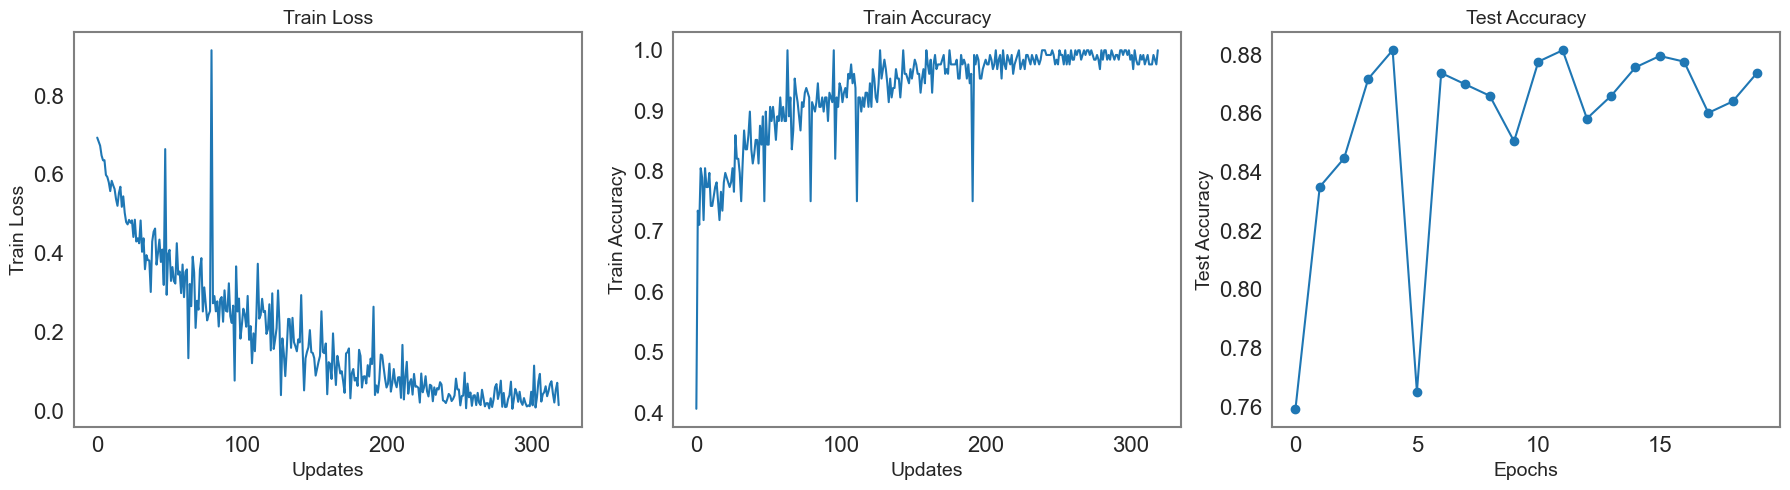

In [20]:
# plot training curves
import matplotlib.pyplot as plt
_, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    ax.set_facecolor("white")
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("grey")   # 外框颜色
        spine.set_linewidth(1.5)   # 外框粗细
axes[0].plot(range(len(train_losses)), train_losses)
axes[0].set_xlabel("Updates", size=14)
axes[0].set_ylabel("Train Loss", size=14)
axes[0].set_title("Train Loss", size=14)
axes[0].grid(False)
axes[1].plot(range(len(train_accuracies)), train_accuracies)
axes[1].set_xlabel("Updates", size=14)
axes[1].set_ylabel("Train Accuracy", size=14)
axes[1].set_title("Train Accuracy", size=14)
axes[1].grid(False)
axes[2].plot(range(len(test_accuracies)), test_accuracies, marker="o")
axes[2].set_xlabel("Epochs", size=14)
axes[2].set_ylabel("Test Accuracy", size=14)
axes[2].set_title("Test Accuracy", size=14)
axes[2].grid(False)

plt.tight_layout()
plt.savefig('BBB_predictor.svg', dpi=300)
plt.show()


COC1CC(C(O)N2CCC(N3CCN(C)CC3)CC2)CCC1NC1NCC2C(N1)N(C)C1CCCCC1C(O)N2C


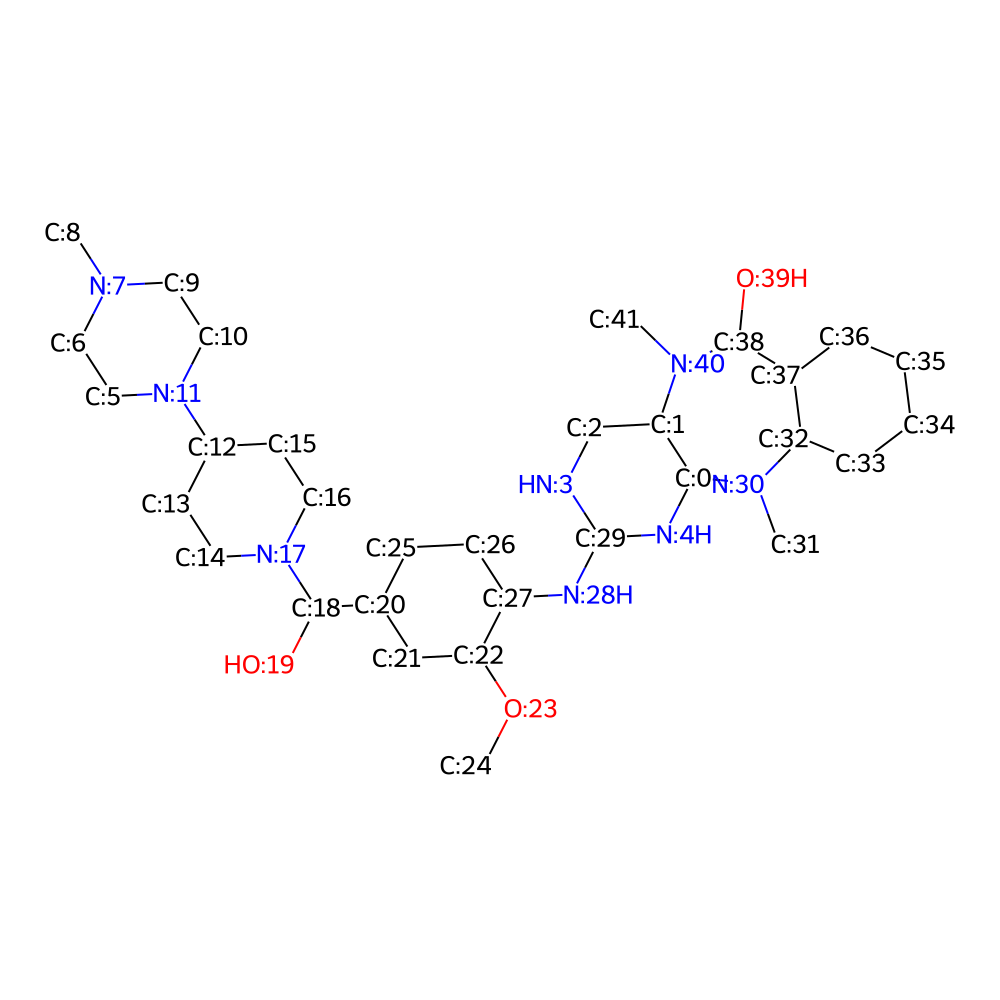

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
mol = Chem.SDMolSupplier('/raid/yyw/PMDM/example/8fo7_ligand.sdf')[0]
smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
print(smiles)
mol.RemoveAllConformers()
for i, atom in enumerate(mol.GetAtoms()):
    atom.SetProp('molAtomMapNumber', str(i))
Draw.MolToImage(mol, size=(1000,1000))

In [4]:
checkpoint = torch.load("BBB_predictor_best.pth")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

VisionLSTM2(
  (patch_embed): VitPatchEmbed(
    (proj): Conv2d(10, 200, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_embed): VitPosEmbed2d()
  (blocks): ModuleList(
    (0-11): 12 x ViLBlockPair(
      (rowwise_from_top_left): ViLBlock(
        (drop_path): DropPath(drop_prob=0.020)
        (norm): LayerNorm()
        (layer): ViLLayer(
          (proj_up): Linear(in_features=200, out_features=800, bias=True)
          (q_proj): LinearHeadwiseExpand(dim=400, num_heads=100, bias=True, )
          (k_proj): LinearHeadwiseExpand(dim=400, num_heads=100, bias=True, )
          (v_proj): LinearHeadwiseExpand(dim=400, num_heads=100, bias=True, )
          (conv): SequenceConv2d(400, 400, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=400)
          (mlstm_cell): MatrixLSTMCell(
            (igate): Linear(in_features=1200, out_features=4, bias=True)
            (fgate): Linear(in_features=1200, out_features=4, bias=True)
            (outnorm): MultiHeadLayerNorm()
          )
   

In [13]:
train_data = pd.read_csv("MoleculeNet-BBBP-process-flow-step5-traindata.csv")
test_data = pd.read_csv("Sdata-process-flow-step5-testdata.csv")

X_=['O=C(C1=CC(OC)=C(NC2=NC=C3C(N(C4=C(C(N3C)=O)C=CC=C4)C)=N2)C=C1)N5CCC(CC5)N6CCN(CC6)C', 'c1ccccc1Oc(cc2)cc(c23)c(n[nH]3)-c4ccncc4', 'c1c[nH]c(c12)nc(nc2C3CC3)Nc4cn[nH]c4', 'FC(F)(F)c1cnc(nc1C)Nc(cc2)cc(c23)[nH]nc3']
data_list=[]
for i, smi in enumerate(X_):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)

inputs = torch.stack(data_list).to("cuda:0")
y_hat = model(inputs)
output_BBB = torch.softmax(y_hat, dim=1)[:, 1]

In [57]:
import random
diffhopp_smis = []
with open('/home/yyw/yyw/Graph-ViL/logs_sample/ZINC250k/test/May14-06_14_20-sample_A3C.txt') as file:
    lines = file.readlines()
    for line in lines:
        line = line.strip()
        diffhopp_smis.append(line)
data_list=[]
for i, smi in enumerate(diffhopp_smis):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)
model.to("cuda:1")
inputs = torch.stack(random.sample(data_list, 100)).to("cuda:1")
y_hat = model(inputs)
output_BBB = torch.softmax(y_hat, dim=1)[:, 1]
preds = (output_BBB > 0.5).long().cpu()
y_pred = preds.numpy()
pop = np.sum(y_pred == 1) / len(y_pred)
print(f'GraphViL output BBB penetation: {pop}')

GraphViL output BBB penetation: 0.96


In [14]:
output_BBB

tensor([0.8406, 0.9970, 0.9943, 0.9964], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [18]:
from mini_moses.metrics.utils import SA, QED
ms = [Chem.MolFromSmiles(s) for s in X_]
sas = [round((10 - SA(m)) / 9, 3) for m in ms if m is not None]

qeds = [QED(m) for m in ms]

In [19]:
sas

[0.798, 0.89, 0.78, 0.826]

In [17]:
qeds

[0.4948637517137081, 0.6066278058554859, 0.655669083061775, 0.759418696276472]

In [20]:
from rdkit import Chem
decompopt_mols = []
for i in range(31):
    mols = Chem.SDMolSupplier(f'/home/yyw/yyw/baselines/Decompopt/sampling_100/sampling_100/sampling_10_ret-ref_prior-100-{i:03d}/eval/mols.sdf')
    for m in mols:
        if m is not None:
            decompopt_mols.append(m)

In [35]:
decompopt_smis = [Chem.MolToSmiles(m) for m in decompopt_mols]
data_list=[]
for i, smi in enumerate(decompopt_smis):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)

inputs = torch.stack(data_list).to("cuda:0")
y_hat = model(inputs)
output_BBB = torch.softmax(y_hat, dim=1)[:, 1]
preds = (output_BBB > 0.5).long().cpu()
y_pred = preds.numpy()
pop = np.sum(y_pred == 1) / len(y_pred)
print(f'Decompopt output BBB penetation: {pop}')

Decompopt output BBB penetation: 0.875


In [45]:
diffhopp_mols = Chem.SDMolSupplier('/home/yyw/yyw/baselines/diffhopp/diffhopp_results.sdf')
diffhopp_smis = [Chem.MolToSmiles(m) for m in diffhopp_mols]
data_list=[]
for i, smi in enumerate(diffhopp_smis):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)
model.to("cuda:1")
inputs = torch.stack(data_list).to("cuda:1")
y_hat = model(inputs)
output_BBB = torch.softmax(y_hat, dim=1)[:, 1]
preds = (output_BBB > 0.5).long().cpu()
y_pred = preds.numpy()
pop = np.sum(y_pred == 1) / len(y_pred)
print(f'diffhopp output BBB penetation: {pop}')

diffhopp output BBB penetation: 0.8757894736842106


In [60]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [50]:
diffhopp_mols = Chem.SDMolSupplier('/home/yyw/yyw/baselines/drlinker/drlinker_outwith_3d.sdf')
diffhopp_smis = [Chem.MolToSmiles(m) for m in diffhopp_mols]
data_list=[]
for i, smi in enumerate(diffhopp_smis):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)
model.to("cuda:0")
inputs = torch.stack(data_list).to("cuda:0")
y_hat = model(inputs)
output_BBB = torch.softmax(y_hat, dim=1)[:, 1]
preds = (output_BBB > 0.5).long().cpu()
y_pred = preds.numpy()
pop = np.sum(y_pred == 1) / len(y_pred)
print(f'drlinker output BBB penetation: {pop}')

drlinker output BBB penetation: 0.9877750611246944


In [51]:
import glob
def load_sdf_folder(folder_path):
    sdf_files = glob.glob(os.path.join(folder_path, "*.sdf"))
    all_mols = []

    for sdf_file in sdf_files:
        suppl = Chem.SDMolSupplier(sdf_file)
        for mol in suppl:
            if mol is not None:
                all_mols.append(mol)

    return all_mols
folder = "/home/yyw/yyw/baselines/PMDM/frag_gen"
molecules = load_sdf_folder(folder)
print(f"成功加载了 {len(molecules)} 个分子")
diffhopp_smis = [Chem.MolToSmiles(m) for m in molecules]
data_list=[]
for i, smi in enumerate(diffhopp_smis):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)
model.to("cuda:0")
inputs = torch.stack(data_list).to("cuda:0")
y_hat = model(inputs)
output_BBB = torch.softmax(y_hat, dim=1)[:, 1]
preds = (output_BBB > 0.5).long().cpu()
y_pred = preds.numpy()
pop = np.sum(y_pred == 1) / len(y_pred)
print(f'PMDM output BBB penetation: {pop}')

成功加载了 813 个分子
PMDM output BBB penetation: 0.7908979089790897


In [52]:
diffhopp_smis = []
with open('/home/yyw/yyw/baselines/Tree-Invent/sampled_mols.smi') as file:
    lines = file.readlines()
    for line in lines:
        line = line.strip()
        diffhopp_smis.append(line)
data_list=[]
for i, smi in enumerate(diffhopp_smis):
    try:
        X, A = smiles_to_graph(smi)
    except:
        continue
    img_tensor = graph_to_image(X, A)
    data_list.append(img_tensor)
model.to("cuda:0")
inputs = torch.stack(data_list).to("cuda:0")
y_hat = model(inputs)
output_BBB = torch.softmax(y_hat, dim=1)[:, 1]
preds = (output_BBB > 0.5).long().cpu()
y_pred = preds.numpy()
pop = np.sum(y_pred == 1) / len(y_pred)
print(f'Tree-Invent output BBB penetation: {pop}')

Tree-Invent output BBB penetation: 0.7012195121951219
